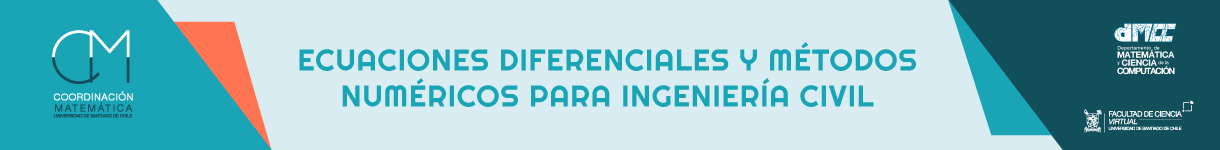

#**Semana 5**:
- Método de Newton-Raphson.
- Método de Bisección.

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
sp.init_printing(use_latex='mathjax')

#Recuerdo:

> <b>Teorema de Bolzano </b>:
Si $f : [a, b] \to \mathbb{R}$, es una función continua en $[a, b]$ y $f(a)\cdot f(b) < 0$, entonces
existe $x_0 \in  [a, b]$ tal que $f(x_0) = 0$.

**Gráficamente:**

Considerando $x_0=c$, si el producto de $f(a)$ con $f(b)$ es negativo, entonces existe un valor $c=x_0$ de modo que la función $f$ (continua) pasa por $(x_0,f(x_0)=0)$.

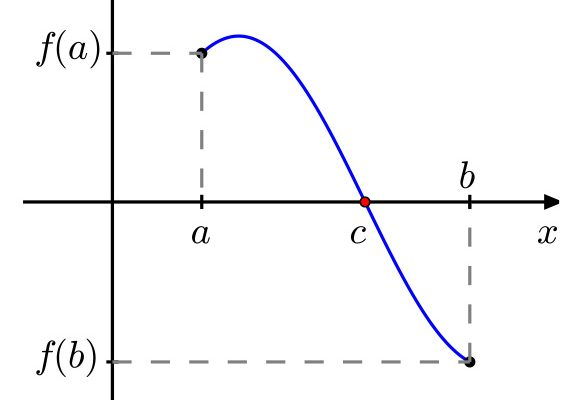

# **Método de Bisección**

Este método de busqueda por bisección es utilizado para encontrar raíces de una
función continua de variable real. La única condición es que la función cambie de
signo en el intervalo en que buscamos. En tal caso, la existencia de la raíz de la función está
garantizada de acuerdo al teorema de Bolzano.

Considere que se desea buscar un cero de la función $f$. Es decir, queremos resolver $$f(x)=0$$

El método consiste en bisecar el intervalo $[a, b]$, estudiar los signos de $f$ en los
extremos de los nuevos intervalos de manera que podamos afirmar la existencia de
una raíz en un intervalo más pequeño como consecuencia del teorema de Bolzano.

## **Algoritmo:** Método de Bisección

Entrada: $a, b,$ función $f$, tolerancia $\varepsilon$.

Calcular: $x_0 =\dfrac{a+b}{2}$

Para $i = 0,1,2, ...$

* Si $f(a)f(x_i) < 0$, entonces $b = x_i$
* Si $f(a)f(x_i) > 0$, entonces $a = x_i$
* Si $f(a)f(x_i) = 0$, entonces $x_{i+1} = x_{i}$

Hasta que $|x_{i+1}-x_{i}|< \varepsilon$

Bisección 2.png

#Ejemplo:

* a) Elabore una función en Python que permita encontrar una aproximación de una raíz de una función $f:[a,b] \to \mathbb{R}$ usando el método de bisección, considerando como datos de entrada $a,b$ y la tolerancia.

* b) Utilice la función anterior y el teorema de Bolzano para encontrar las cuatro raíces de $f(x)=10x^3-2x^2+1-e^{2x}$. **Ayuda:** las raíces se encuentran en el intervalo $[-1,3]$, verifique esto graficando la función.

In [3]:
#a)
def biseccion(f, a, b, tol, max_iteraciones):
    # Verificar la condición del Teorema de Bolzano
    if f(a) * f(b) >= 0:
        raise ValueError("La función debe cambiar de signo en el intervalo [a, b].")

    x_i = (a + b) / 2
    x_old = b # Inicializamos x_old para que |x_i - x_old| sea mayor que tol al principio

    for i in range(max_iteraciones):
        # Criterio de parada: |x_{i+1} - x_i| < ε
        if abs(x_i - x_old) < tol:
            print(f"Raíz encontrada en {i+1} iteraciones.")
            return x_i

        x_old = x_i # Guardar el valor actual de x_i para la próxima iteración

        if f(a) * f(x_i) < 0:
            b = x_i
        elif f(a) * f(x_i) > 0:
            a = x_i
        else: # f(a) * f(x_i) == 0, lo que significa que f(x_i) es 0
            print(f"Raíz exacta encontrada en {i+1} iteraciones.")
            return x_i

        x_i = (a + b) / 2 # Recalcular el nuevo punto medio

    raise RuntimeError("No se encontró una raíz dentro del número máximo de iteraciones.")

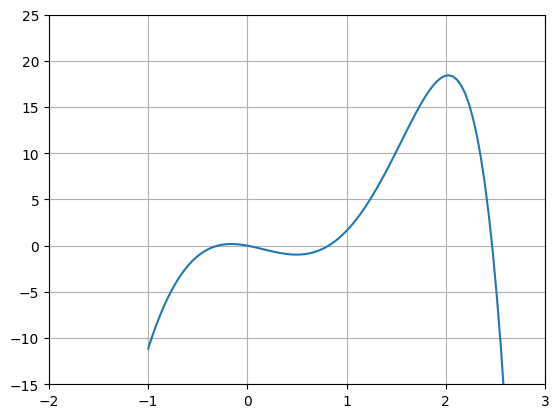

In [5]:
#b) Graficamos la función f(x)=10x^3-2x^2+1-e^{2x}

X=np.linspace(-1,3,100)
Y=10*X**3-2*X**2+1-np.exp(2*X)

plt.plot(X,Y)
plt.xlim(-2, 3)
plt.ylim(-15, 25)
plt.grid()
plt.show()

In [6]:
def f(z):
    return 10*z**3-2*z**2+1-np.exp(2*z)

print(biseccion(f, -1, -0.2, 10**-5, 100))
print(biseccion(f, -0.2, 0.5, 10**-5, 100))
print(biseccion(f, 0.5, 1, 10**-5, 100))
print(biseccion(f, 2, 3, 10**-5, 100))


Raíz encontrada en 17 iteraciones.
-0.300421142578125
Raíz encontrada en 17 iteraciones.
-7.629394531329302e-07
Raíz encontrada en 16 iteraciones.
0.8179092407226562
Raíz encontrada en 17 iteraciones.
2.4673538208007812


# **Método de Newtwon - Raphson**

Este método es uno de los más populares para encontrar los ceros de una función, pero
requiere del conocimiento de su derivada. Considere que se desea buscar un cero de la función $f$. Es decir, queremos resolver $$f(x)=0$$

En este algortimo, dado un punto $x_k$ cercano a la raíz de $f$, se determina la recta tangente a $f$
en $(x_k, f(x_k))$: <br>

$$y = f(x_k) + f'(x_k)(x - x_k)$$

Luego, se define la iteración siguiente $x_{k+1}$ como el punto de intersección entre esa
recta y el eje $x$, es decir, $x_{k+1}$ se obtiene al despejar

$$0 = f(x_k) + f(x_k)(x_{k+1} - x_k)$$

esto es
$$ x_{k+1} = x_k - \dfrac{f(x_k)}{f'(x_k)}  $$

## **Algoritmo:** Método de Newton - Raphson

Entrada: $x_0$, función $f$ , tolerancia $\varepsilon$

Para $k = 0, 1, 2, ...$

* calcular $x_{k+1} = x_k - \dfrac{f(x_k)}{f'(x_k)}$

Hasta que $| x_{k+1} - x_k | < \varepsilon$


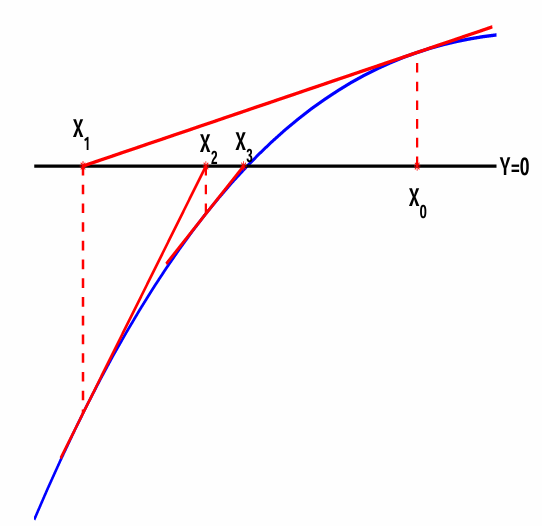

# Ejemplo:

Elabore una función en Python que permita encontrar una aproximación de un cero de una función $f:[a,b] \to \mathbb{R}$ usando el método de Newton-Raphson, considerando como datos de entrada un valor cercano a la raíz $x_0$, la función en cuestión $f$, su derivada $f'$ y la tolerancia $tol$.

In [7]:
def newton_raphson(f, df, x0, tol, max_iter=100):
    """
    Aproxima la raíz de una función utilizando el método de Newton-Raphson.
    
    Parámetros:
    f        : Función objetivo definida mediante 'def' f(x).
    df       : Derivada de la función f definida mediante 'def' df(x).
    x0       : Valor inicial (aproximación cercana a la raíz).
    tol      : Tolerancia permitida para el criterio de parada.
    max_iter : Número máximo de iteraciones para evitar bucles infinitos.
    
    Retorna:
    Una aproximación a la raíz, o None si no converge.
    """
    x = x0
    
    for i in range(max_iter):
        fx = f(x)
        dfx = df(x)
        
        # Evitar la división por cero si la derivada es muy cercana a 0
        if abs(dfx) < 1e-12:
            print(f"Error: La derivada se hizo cero o muy cercana a cero en la iteración {i}.")
            return None
            
        # Fórmula de Newton-Raphson
        x_nueva = x - fx / dfx
        
        # Criterio de parada: la diferencia entre iteraciones es menor a la tolerancia
        if abs(x_nueva - x) < tol:
            print(f"Raíz encontrada en la iteración {i+1}.")
            return x_nueva
            
        x = x_nueva
        
    print(f"Advertencia: El método no convergió tras {max_iter} iteraciones.")
    return x

# Ejemplo:

Elabore una función de Python que permita encontrar una aproximación de una raíz de una función $f:[a,b]\rightarrow \mathbb{R}$ usando el método de Newton-Rapshon, considerando los parámetros: la función $f$, la variable independiente (simbólica), $x_0$: punto inicial, $N$: máximo de iteraciones.

In [8]:
def NR(f_sym, symbol, x0, tol, max_iter):
    # Ahora la función recibe la variable simbólica sobre la que operar
    df_sym = sp.diff(f_sym, symbol)

    # Convertir las expresiones simbólicas a funciones numéricas usando la variable correcta
    f_num = sp.lambdify(symbol, f_sym, 'numpy')
    df_num = sp.lambdify(symbol, df_sym, 'numpy')

    xn = x0
    for i in range(max_iter):
        fxn = f_num(xn)
        dfxn = df_num(xn)

        if abs(dfxn) < 1e-10:  # Evitar división por cero o derivada muy cercana a cero
            raise ValueError("La derivada es cero o muy cercana a cero en este punto. El método de Newton-Raphson no puede continuar.")

        x_next = xn - fxn / dfxn

        if abs(x_next - xn) < tol:
            print(f"Raíz encontrada en {i+1} iteraciones.")
            return x_next

        xn = x_next

    raise RuntimeError("No se encontró una raíz dentro del número máximo de iteraciones.")

#Ejercicio 1

La ecuación $\ln(2x) = \dfrac{x}{2}$ tiene dos soluciones. Utilice el método de la bisección y Newton-Raphson con un error máximo de $10^{-8}$ para estimar las soluciones de la ecuación. Justifique su razonamiento para aplicar el método:

   * Formulación de la función a utilizar.
   * Elección de intervalo.
   * Elección de la tolerancia.

$f(x)=0$

$ln(2x)-\frac{x}{2}=0$

$f(x)=ln(2x)-\frac{x}{2}$

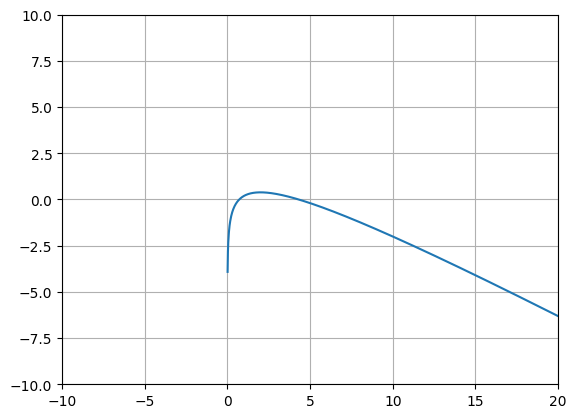

Raíz encontrada en 19 iteraciones.
0.7148048400878907
Raíz encontrada en 18 iteraciones.
4.306587219238281
Raíz encontrada en 6 iteraciones.
Una raíz de ln(2x) = x/2 es: 0.7148059123627778
Raíz encontrada en 4 iteraciones.
La segunda raíz de ln(2x) = x/2 es: 4.306584728220699


In [10]:
# Definir la variable simbólica
x = sp.symbols('x')

# Definir la función como una expresión simbólica
f_sym = sp.log(2*x) - x/2

#Graficamos la función para obtener una pista de dónde se encuentran las raíces
X=np.linspace(0.01 , 20, 1000)

faux=sp.lambdify(x,f_sym,'numpy')
plt.plot(X,faux(X))
#plt.plot(X,np.log(2*X)-X/2)

plt.xlim(-10, 20)
plt.ylim(-10,10)
plt.grid()
plt.show()

#Usando bisección
print(biseccion(faux,0.2,3,1e-5,100))
print(biseccion(faux,3,5,1e-5,100))

# Parámetros para el método de Newton-Raphson
x0 = 1.0                # Valor inicial cercano a una de las raíces (observando la gráfica de ln(2x) y x/2)
tol = 1e-8
max_iter = 100

# Encontrar la raíz usando la función definida de manera simbólica
raiz = NR(f_sym,x, x0, tol, max_iter)
print(f"Una raíz de ln(2x) = x/2 es: {raiz}")

# Intentemos encontrar la otra raíz, que parece estar alrededor de x=5
x0_2 = 5.0
raiz_2 = NR(f_sym, x,x0_2, tol, max_iter)
print(f"La segunda raíz de ln(2x) = x/2 es: {raiz_2}")


# Ejercicio 2

Encuentre la solución(es) a la ecuación:
$$\dfrac{1}{1-x}=e^x$$
en el intervalo $[-0.5,\, 1]$ mediante el método de bisección, si es posible. En caso contrario, justifique.

Respuesta: No se puede ya que la funcion no esta definida en f(1) y ambos lados de la ecuacion son siempre positivos en el intervalo


# Ejercicio 3

Encontrar utilizando el método de bisección una aproximación de $\sqrt[3]{7}$.

#Ejercicio 4

Una canaleta  de largo $L$ tiene por sección tranversal forma de semicircunferencia de radio $r$ (ambos medidos en $cm$), como muestra la figura a contianuación:

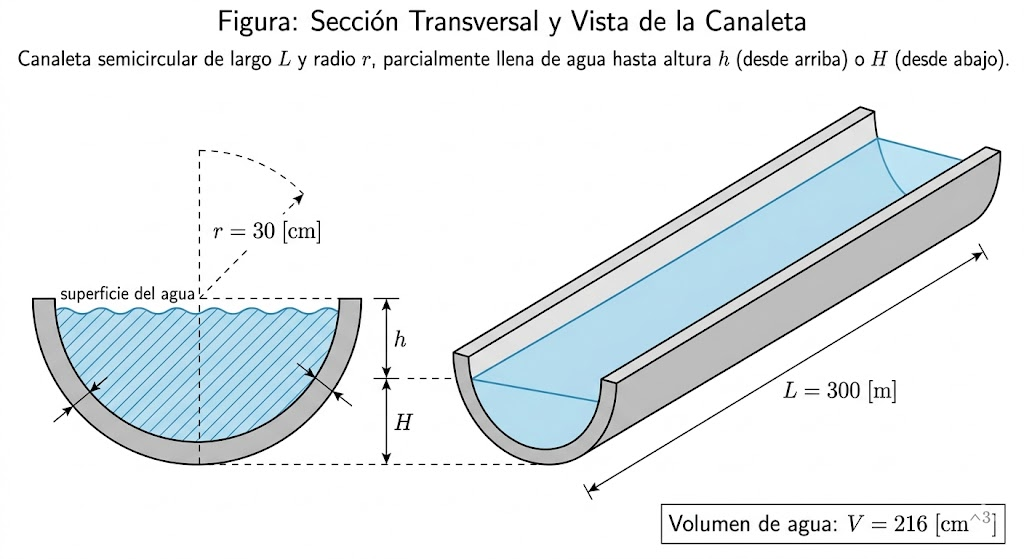

Cuando se llena de agua hasta una distancia $h$ de su parte superior, el volumen $V$ de agua es

$$V=L\left[ \frac{1}{2}\pi r^2 - r^2\arcsin\left(\frac{h}{r} \right) - h\sqrt{r^2-h^2} \right]$$

Suponga que el $L=300 [m]$, $r=30 [cm]$ y el volumen de agua es $V=216 [cm^3]$. Encuentre una aproximación de la altura del agua desde la base de la canaleta.


In [19]:
# 1. Definimos las constantes del problema

L = 30000.0  # cm
r = 30.0     # cm
V = 216.0    # cm^3

# 2. Definimos la función f(h)
def f(h):
    area_semicirculo = 0.5 * np.pi * (r**2)
    termino_arcsin = (r**2) * np.asin(h / r)
    termino_raiz = h * np.sqrt(r**2 - h**2)
    return L * (area_semicirculo - termino_arcsin - termino_raiz) - V

# 3. Definimos la derivada f'(h) simplificada
def df(h):
    return -2.0 * L * (r**2 - h**2)**0.5

h_inicial = 29.9

print("Valor aproximado de h:", biseccion(f, 0, 30, 1e-5, 100))

Raíz encontrada en 22 iteraciones.
Valor aproximado de h: 29.99213933944702


# Ejercicio 5

Encuentre aproximaciones de los ejercicios previos, utilizando el método de Newton-Raphson, justificando su elección de $x_0$.

In [21]:
# Pregunta 2
def f_pregunta2(x):
    return 1/(1-x) - np.exp(x)

def df_pregunta2(x):
    return 1/(1-x)**2 - np.exp(x)

print(newton_raphson(f_pregunta2, df_pregunta2, 0.5, tol=1e-5, max_iter=100))

Raíz encontrada en la iteración 18.
5.07372753955256e-06


In [22]:
print(newton_raphson(f, df, 0, tol=1e-5, max_iter=100))

Raíz encontrada en la iteración 10.
29.99213756932324


# Ejercicio 6
En la Semana 4 resolvimos un problema relacionado a un circuito que era modelado por la ecuación:

$$ RC \frac{d v_c}{dt} + v_c = V(t) $$

Donde $V(t)$ era el voltaje de entrada, $v_c(t)$ el voltaje en el capacitor, $t$ el tiempo, $R=2 [\Omega]$, $C=0.2 [F]$

Para la condición inicial $v_c(0)=2$ y un voltaje de entrada 20 $[V]$ resuelva el PVI de manera simbólica y use un método numérico, Bisección o Newton-Raphson, para aproximar el tiempo $T$ en que $v_c=15 [V]$.

             d              
v_c(t) + 0.4⋅──(v_c(t)) = 20
             dt             

                      -2.5⋅t
v_c(t) = 20.0 - 18.0⋅ℯ      

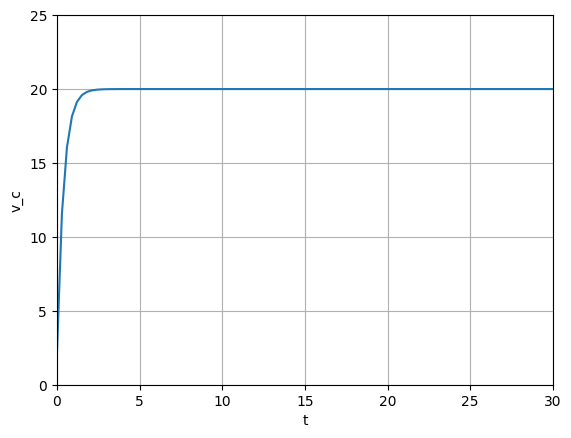

In [24]:
#Resolvemos el PVI

t=sp.symbols('t')
v_c=sp.Function('v_c')

R=2
C=0.2

ec=sp.Eq((R*C)*v_c(t).diff(t)+v_c(t),20)
display(ec)

sol=sp.dsolve(ec,ics={v_c(0):2})
display(sol)

#Graficamos la solución para visualizarla

faux=sp.lambdify(t,sol.rhs,'numpy')
X=np.linspace(0,30,100)
Y=faux(X)

plt.grid()
plt.xlim(0,30)
plt.ylim(0,25)
plt.xlabel('t')
plt.ylabel('v_c')
plt.plot(X,Y)
plt.show()

$v_c(T)=15$

$v_c(T)-15=0$

$g(x)=v_c(x)-15=20-18e^{-2.5t}-15$

In [25]:
#Ahora, buscamos T tal que v_c(T)=15 usando Newton Raphson
expresionsol=sol.rhs
g=expresionsol-15

# Usamos la función NR dando como parámetros (función,variable,punto inicial,tolerancia, max iteraciones)
NR(g, t, 2, 1e-5, 100)

Raíz encontrada en 42 iteraciones.


np.float64(0.5123735381848225)